<a href="https://colab.research.google.com/github/k-vinod-kumar-reddy18/crop_recommendation/blob/main/crop_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Crop_recommendation.csv to Crop_recommendation.csv


In [21]:
df = pd.read_csv('/Crop_recommendation.csv')
print("Data shape:", df.shape)
df.head()

Data shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [22]:
from sklearn.model_selection import train_test_split

X = df.drop('label', axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (1760, 7)
X_test shape: (440, 7)
y_train shape: (1760,)
y_test shape: (440,)


In [23]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train_encoded)
print("XGBoost Classifier trained successfully with encoded labels.")

XGBoost Classifier trained successfully with encoded labels.


In [24]:
from sklearn.metrics import accuracy_score

y_pred_encoded = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test_encoded, y_pred_encoded)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9841


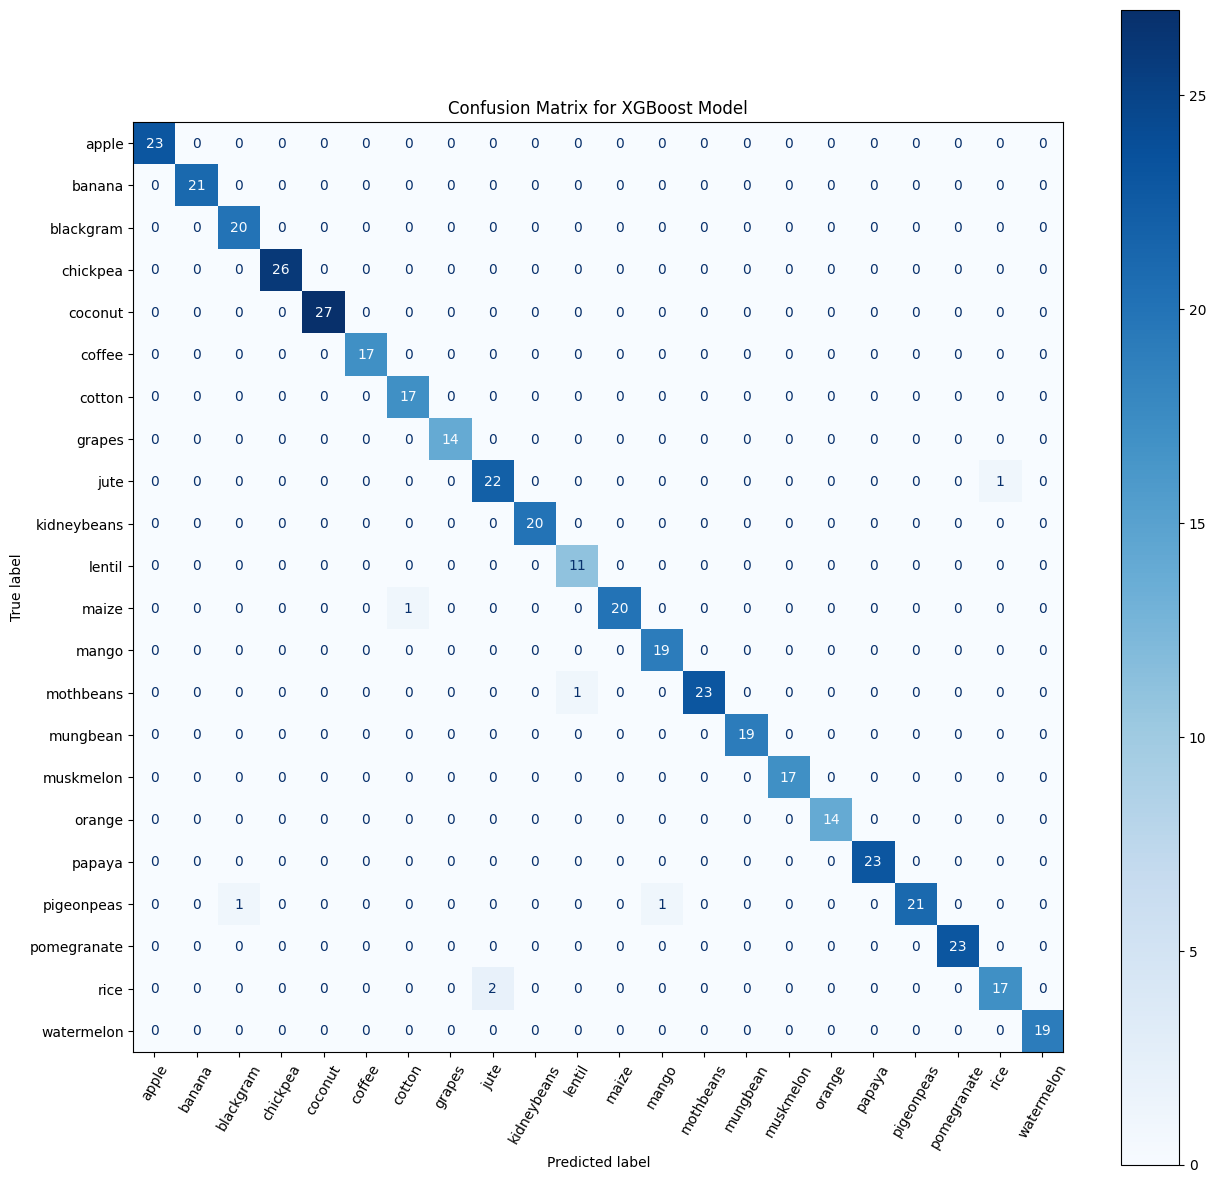

Confusion Matrix displayed successfully.


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test_encoded, y_pred_encoded)

# Create ConfusionMatrixDisplay object with original labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

# Set figure size for better readability of many labels
plt.figure(figsize=(15,15))

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues, ax=plt.gca())
plt.title("Confusion Matrix for XGBoost Model")
plt.xticks(rotation=60)
plt.show()
print("Confusion Matrix displayed successfully.")

In [26]:
from sklearn.metrics import classification_report

# Generate the classification report
report = classification_report(y_test_encoded, y_pred_encoded, target_names=le.classes_)

print("Classification Report for XGBoost Model:")
print(report)

Classification Report for XGBoost Model:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      0.96      0.94        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      0.95      0.98        21
       mango       0.95      1.00      0.97        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1

In [27]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate

# Encode the full target variable 'y' for cross-validation
y_encoded = le.transform(y)

# Instantiate StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring metrics for cross-validation
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

# Perform cross-validation with multiple scoring metrics
cv_results = cross_validate(xgb_model, X, y_encoded, cv=skf, scoring=scoring)

# Extract mean and standard deviation for each metric
mean_accuracy = cv_results['test_accuracy'].mean()
std_accuracy = cv_results['test_accuracy'].std()

mean_precision = cv_results['test_precision_weighted'].mean()
std_precision = cv_results['test_precision_weighted'].std()

mean_recall = cv_results['test_recall_weighted'].mean()
std_recall = cv_results['test_recall_weighted'].std()

mean_f1 = cv_results['test_f1_weighted'].mean()
std_f1 = cv_results['test_f1_weighted'].std()

print(f"Cross-Validation Mean Accuracy: {mean_accuracy:.4f} (Std: {std_accuracy:.4f})")
print(f"Cross-Validation Mean Precision: {mean_precision:.4f} (Std: {std_precision:.4f})")
print(f"Cross-Validation Mean Recall: {mean_recall:.4f} (Std: {std_recall:.4f})")
print(f"Cross-Validation Mean F1-Score: {mean_f1:.4f} (Std: {std_f1:.4f})")

Cross-Validation Mean Accuracy: 0.9932 (Std: 0.0051)
Cross-Validation Mean Precision: 0.9938 (Std: 0.0047)
Cross-Validation Mean Recall: 0.9932 (Std: 0.0051)
Cross-Validation Mean F1-Score: 0.9931 (Std: 0.0052)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [16:25:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


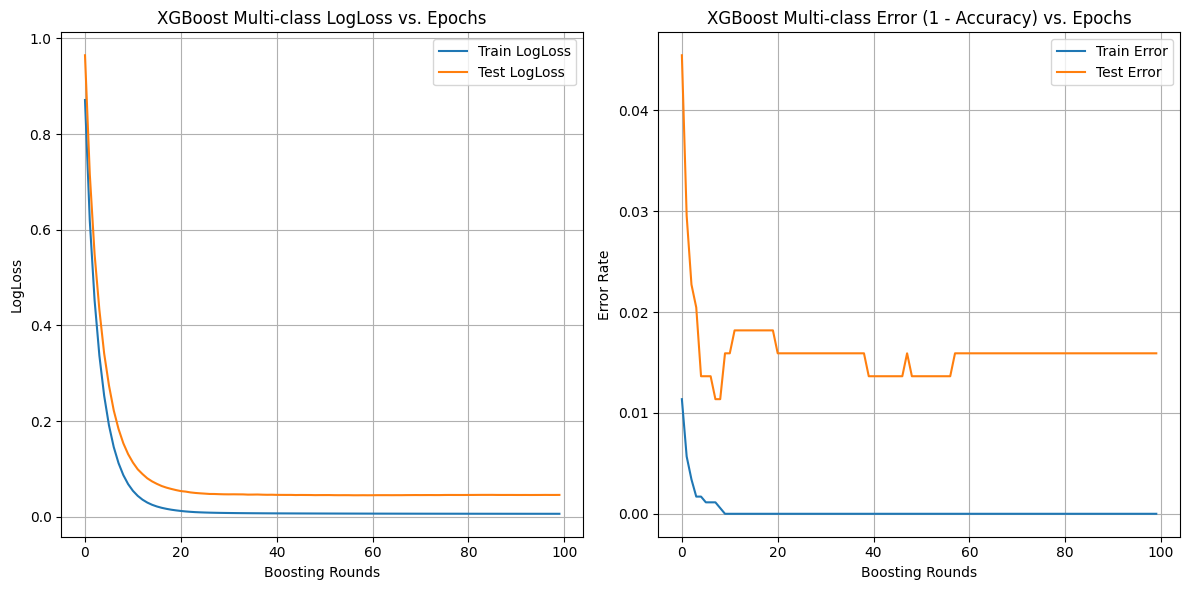

Loss and Error (1-Accuracy) graphs displayed successfully.


In [28]:
# Re-train XGBoost model with eval_set to capture metrics during training
xgb_model_eval = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric=['mlogloss', 'merror']) # Suppress use_label_encoder warning and specify eval metrics

eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)]

xgb_model_eval.fit(X_train, y_train_encoded,
                   eval_set=eval_set,
                   verbose=False) # Set verbose to False to suppress frequent output

# Retrieve evaluation results
results = xgb_model_eval.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x = range(epochs)

# Plot mlogloss (multi-class logloss) and merror (multi-class error)
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1) # Subplot for LogLoss
plt.plot(x, results['validation_0']['mlogloss'], label='Train LogLoss')
plt.plot(x, results['validation_1']['mlogloss'], label='Test LogLoss')
plt.legend()
plt.title('XGBoost Multi-class LogLoss vs. Epochs')
plt.xlabel('Boosting Rounds')
plt.ylabel('LogLoss')
plt.grid(True)

plt.subplot(1, 2, 2) # Subplot for Error (1 - Accuracy)
plt.plot(x, results['validation_0']['merror'], label='Train Error')
plt.plot(x, results['validation_1']['merror'], label='Test Error')
plt.legend()
plt.title('XGBoost Multi-class Error (1 - Accuracy) vs. Epochs')
plt.xlabel('Boosting Rounds')
plt.ylabel('Error Rate')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Loss and Error (1-Accuracy) graphs displayed successfully.")

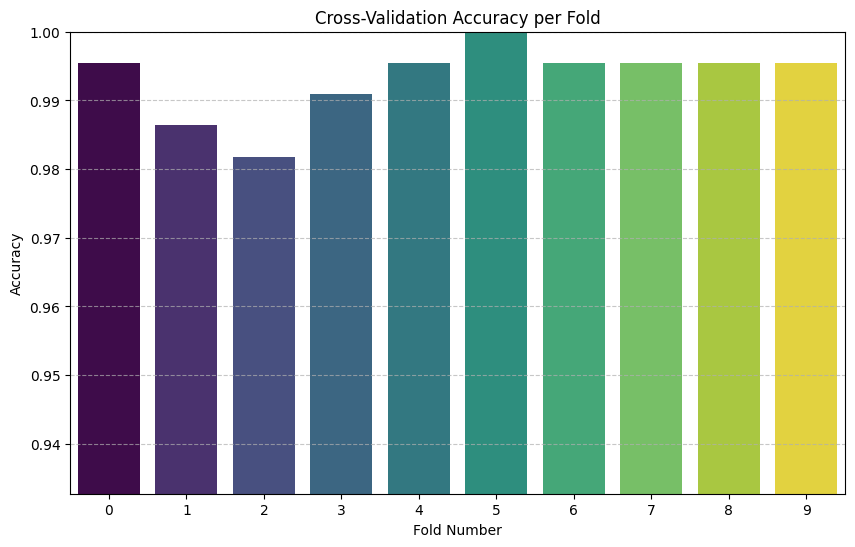

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming cv_results is already available from previous execution
# cv_results = {'fit_time': ..., 'score_time': ..., 'test_accuracy': array([...])}

plt.figure(figsize=(10, 6))
sns.barplot(x=list(range(len(cv_results['test_accuracy']))), y=cv_results['test_accuracy'], palette='viridis', hue=list(range(len(cv_results['test_accuracy']))), legend=False)
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold')
plt.ylim(min(cv_results['test_accuracy']) * 0.95, 1.0) # Set y-axis limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Instantiate an SVC classifier
svm_model = SVC(random_state=42)

# Train the SVM model on the training data
svm_model.fit(X_train, y_train_encoded)
print("SVM model trained successfully.")

# Make predictions on the test data
y_pred_svm = svm_model.predict(X_test)

# Calculate the accuracy of the SVM model
accuracy_svm = accuracy_score(y_test_encoded, y_pred_svm)
print(f"SVM Model Accuracy: {accuracy_svm:.4f}")

SVM model trained successfully.
SVM Model Accuracy: 0.9614


In [31]:
from sklearn.neighbors import KNeighborsClassifier

# Instantiate a KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5) # Using n_neighbors=5 as an example

# Train the KNN model on the training data
knn_model.fit(X_train, y_train_encoded)
print("KNN model trained successfully.")

# Make predictions on the test data
y_pred_knn = knn_model.predict(X_test)

# Calculate the accuracy of the KNN model
accuracy_knn = accuracy_score(y_test_encoded, y_pred_knn)
print(f"KNN Model Accuracy: {accuracy_knn:.4f}")

KNN model trained successfully.
KNN Model Accuracy: 0.9705


In [32]:
from sklearn.tree import DecisionTreeClassifier

# Instantiate a DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the Decision Tree model on the training data
dt_model.fit(X_train, y_train_encoded)
print("Decision Tree model trained successfully.")

# Make predictions on the test data
y_pred_dt = dt_model.predict(X_test)

# Calculate the accuracy of the Decision Tree model
accuracy_dt = accuracy_score(y_test_encoded, y_pred_dt)
print(f"Decision Tree Model Accuracy: {accuracy_dt:.4f}")

Decision Tree model trained successfully.
Decision Tree Model Accuracy: 0.9864


In [33]:
model_accuracies_selected = {
    'XGBoost': accuracy,
    'SVM': accuracy_svm,
    'KNN': accuracy_knn,
    'Decision Tree': accuracy_dt
}

selected_accuracies_df = pd.DataFrame(list(model_accuracies_selected.items()), columns=['Model', 'Accuracy'])
print("Selected Model Accuracies:")
print(selected_accuracies_df)

Selected Model Accuracies:
           Model  Accuracy
0        XGBoost  0.984091
1            SVM  0.961364
2            KNN  0.970455
3  Decision Tree  0.986364


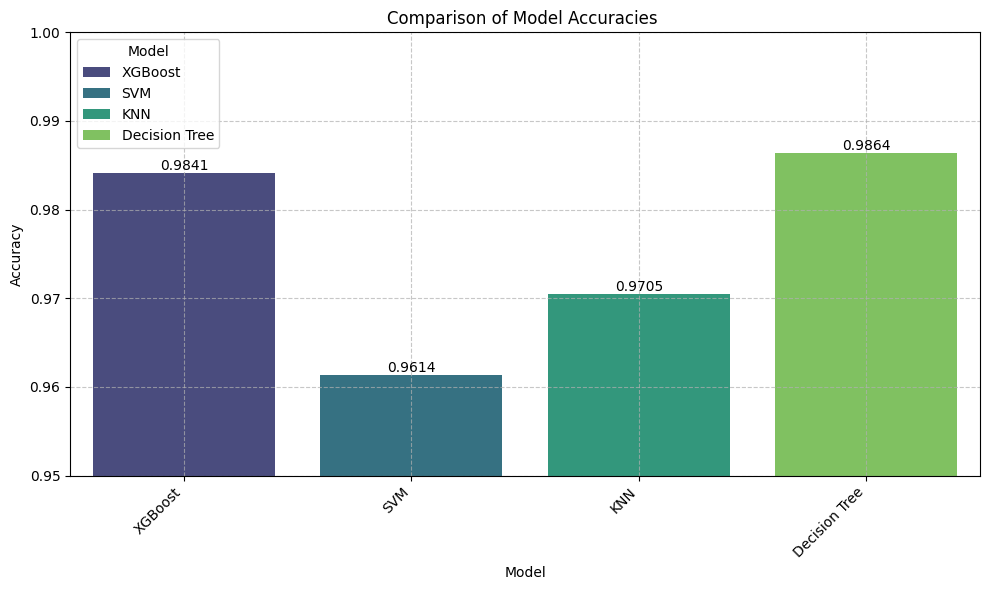

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Accuracy', data=selected_accuracies_df, palette='viridis', hue='Model', legend=True)

# Display accuracy values above each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f') # Format to 4 decimal places for accuracy

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies ')
plt.ylim(0.95, 1.00) # Adjust y-axis limit as requested
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for advanced visualization
plt.tight_layout()
plt.show()



In [35]:
!pip install streamlit pyngrok googletrans==4.0.0-rc1 requests

In [37]:
import pandas as pd
import pickle
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv("/Crop_recommendation.csv")

# Features
X = data[["N","P","K","temperature","humidity","ph","rainfall"]]

# Target
y = data["label"]

# Encode crop names
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# Train XGBoost model
model = XGBClassifier()
model.fit(X_train, y_train)

# Accuracy
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

# Save model
pickle.dump(model, open("crop_model.pkl", "wb"))

# Save encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Model saved successfully!")

Accuracy: 0.9840909090909091
Model saved successfully!


In [38]:
import os
os.listdir()


['.config',
 'Crop_recommendation.csv',
 'crop_model.pkl',
 'label_encoder.pkl',
 'sample_data']

In [39]:
from google.colab import files

files.download("crop_model.pkl")
files.download("label_encoder.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>